In [1]:
from sklearn.model_selection import TimeSeriesSplit
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path(__vsc_ipynb_file__).parent / "working_mo_df.csv"
raw_df = pd.read_csv(DATA_PATH)
raw_df

,Date,VIX_Close,Price To Book Value Per Share(Time Series Ratio),MO_Bid,MO_Ask,Company Market Cap,Net Debt,Net Cash Flow from Operating Activities,Short-Term Debt & Current Portion of Long-Term Debt,Debt - Long-Term - Total,...,Interpolated Government Spread,30D_A_IM_C,30D_A_IM_P,60D_A_IM_C,60D_A_IM_P,90D_A_IM_C,90D_A_IM_P,dd,basis_bps,edf_pct
0,2016-01-15,27.02,38.846853,57.19,57.20,1.121154e+11,10478000000,5843000000,4000000,12843000000,...,123.4458,23.48,23.48,21.50,21.50,21.17,21.17,15.603597,214.051184,0.04
1,2016-01-19,26.05,39.661822,58.40,58.41,1.144675e+11,10478000000,5843000000,4000000,12843000000,...,123.2495,22.11,22.11,21.62,21.62,21.29,21.29,15.339676,214.051184,0.04
2,2016-01-20,27.59,38.860436,57.21,57.22,1.121546e+11,10478000000,5843000000,4000000,12843000000,...,125.0509,25.29,25.29,23.34,23.34,22.70,22.70,14.997837,214.051184,0.04
3,2016-01-21,26.69,39.016638,57.45,57.46,1.126054e+11,10478000000,5843000000,4000000,12843000000,...,125.1433,23.61,23.61,22.43,22.43,22.09,22.09,14.999573,214.051184,0.04
4,2016-01-22,22.34,39.580325,58.27,58.28,1.142323e+11,10478000000,5843000000,4000000,12843000000,...,124.8558,21.05,21.05,19.22,19.22,20.04,20.04,15.094406,214.051184,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2026-01-12,15.12,-37.149486,58.52,58.53,9.801459e+10,21799000000,8753000000,1527000000,23399000000,...,89.6124,20.87,20.87,20.00,20.00,19.88,19.88,10.636751,214.051184,0.04
2496,2026-01-13,15.98,-38.171192,60.13,60.14,1.007102e+11,21799000000,8753000000,1527000000,23399000000,...,65.6160,18.53,18.53,19.41,19.41,19.32,19.32,10.401159,214.051184,0.04
2497,2026-01-14,16.75,-39.008864,61.48,61.49,1.029203e+11,21799000000,8753000000,1527000000,23399000000,...,66.2530,21.09,21.09,19.34,19.34,19.20,19.20,10.300490,214.051184,0.04
2498,2026-01-15,15.84,-39.078670,61.58,61.59,1.031045e+11,21799000000,8753000000,1527000000,23399000000,...,64.9396,20.94,20.94,19.31,19.31,19.37,19.37,10.307388,214.051184,0.04


In [3]:
df = raw_df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

# 30-day forward log-change in Z-spread (Predicting the next month)
# df['target_30d_log_delta_z'] = np.log(df['Z Spread'].shift(-30).clip(lower=5)) - np.log(df['Z Spread'].clip(lower=5))
# Neutralize against macro noise (VIX) to isolate Altria's idiosyncratic "Alpha"
mo_log_move = np.log(df['Z Spread'].shift(-30).clip(lower=5)) - np.log(df['Z Spread'].clip(lower=5))
vix_log_move = np.log(df['VIX_Close'].shift(-30).clip(lower=5)) - np.log(df['VIX_Close'].clip(lower=5))
df['target_residual'] = mo_log_move - vix_log_move

# DD Velocity: Is the firm moving toward or away from the default boundary?
df['dd_velocity_21d'] = df['dd'].diff(21)
df['dd_velocity_5d'] = df['dd'].diff(5)

df['term_structure_30_90'] = df['30D_A_IM_P'] - df['90D_A_IM_P']
df['term_structure_30_60'] = df['30D_A_IM_P'] - df['60D_A_IM_P']

# Velocity of Volatility
df['vol_30d_velocity'] = df['30D_A_IM_P'].diff(5) 

# Relative Volatility (How jumpy is it relative to the average?)
df['vol_zscore'] = (df['30D_A_IM_P'] - df['30D_A_IM_P'].rolling(252).mean()) / df['30D_A_IM_P'].rolling(252).std()

# Leverage Ratio: Standard credit anchor
df['leverage_ratio'] = df['Net Debt'] / df['Earnings before Interest Taxes Depreciation & Amortization'].replace(0, np.nan)
df['leverage_velocity_63d'] = df['leverage_ratio'].diff(63) # Quarterly change trend

df['asset_cushion'] = df['Total Assets'] / (df['Short-Term Debt & Current Portion of Long-Term Debt'] + df['Debt - Long-Term - Total']).replace(0, np.nan)

df['dts'] = df['Modified Duration'] * df['Z Spread']


# VIX Z-Score: Market panic relative to the last year
df['vix_rolling_mean'] = df['VIX_Close'].rolling(window=252).mean()
df['vix_rolling_std'] = df['VIX_Close'].rolling(window=252).std()
df['vix_zscore'] = (df['VIX_Close'] - df['vix_rolling_mean']) / df['vix_rolling_std'].replace(0, np.nan)

# Negative Equity Regime Flag; Important for Altria's 2026 data where P/B is negative
df['is_negative_equity'] = (df['Price To Book Value Per Share(Time Series Ratio)'] < 0).astype(int)

df['dd_x_neg_equity'] = df['dd'] * df['is_negative_equity']

# Drop the intermediate rolling columns used for Z-score
df = df.drop(columns=['vix_rolling_mean', 'vix_rolling_std'])

# List of finalized features for the model
feature_cols = [
    'dd', 'dd_velocity_21d', 'term_structure_30_90', 'term_structure_30_60', 'vol_30d_velocity', 'vol_zscore',
    'leverage_ratio', 'leverage_velocity_63d', 'asset_cushion',
    'dts', 'vix_zscore', 'is_negative_equity', 'Convexity', 'dd_x_neg_equity'
]

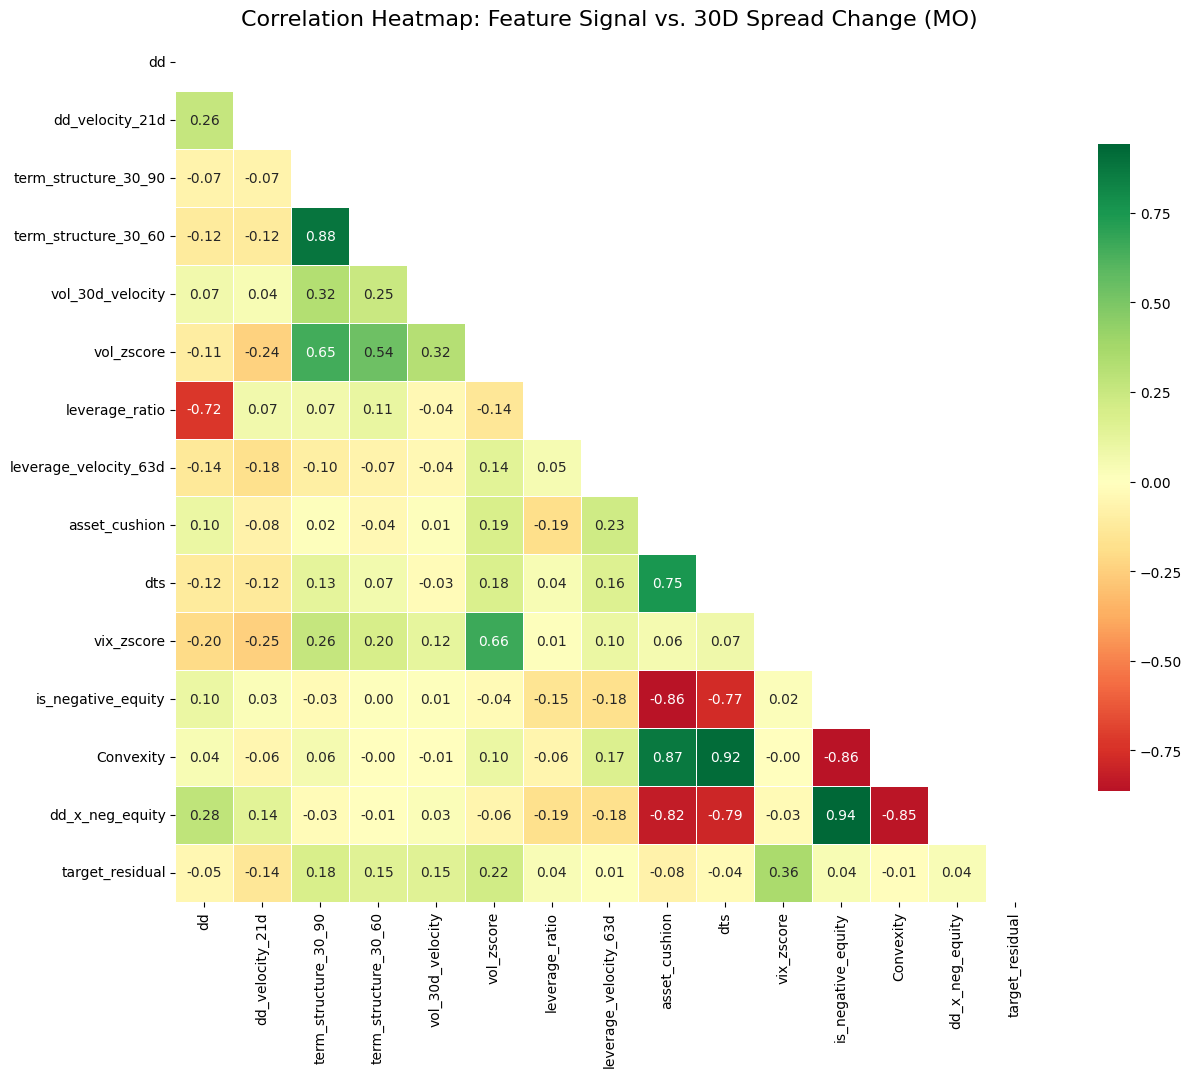

In [4]:
# 1. Define the subset of columns (Features + Target)
cols_to_check = feature_cols + ['target_residual'] #['target_30d_log_delta_z']


# 2. Compute the correlation matrix
# 'spearman' is preferred for credit/vol data which is rarely normally distributed
corr_matrix = df[cols_to_check].dropna().corr(method='spearman')

# 3. Create a mask for the upper triangle (optional, for cleaner look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Plotting
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap='RdYlGn', # Red for negative, Green for positive
    center=0, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .7}
)

plt.title("Correlation Heatmap: Feature Signal vs. 30D Spread Change (MO)", fontsize=16)
plt.show()

Final pruning is essential to mitigate multicollinearity, preventing redundant features from cannibalizing each other’s importance and muddying the interpretability of SHAP values. 

By removing Convexity in favor of the 0.92-correlated DTS, the model is forced to attribute spread sensitivity to a single, industry-standard risk anchor. Prioritizing the 30/90 term structure and the continuous asset_cushion similarly streamlines the input space by favoring robust, granular signals over their binary or overlapping counterparts. 

This surgical cleanup ensures the XGBoost regressor identifies distinct credit regimes for Altria without being distracted by mathematical noise.

In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

df['dd_x_neg_equity'] = df['dd'] * df['is_negative_equity']

mo_log_move = np.log(df['Z Spread'].shift(-30).clip(lower=5)) - np.log(df['Z Spread'].clip(lower=5))
vix_log_move = np.log(df['VIX_Close'].shift(-30).clip(lower=5)) - np.log(df['VIX_Close'].clip(lower=5))

# Target is 1 if MO widens MORE than the VIX (Relative underperformance)
y_residual = (mo_log_move - vix_log_move)
y_class = (y_residual > 0).astype(int)

final_features = [
    'dd', 'leverage_velocity_63d', 'dts', 
    'dd_velocity_21d', 'term_structure_30_90', 'vix_zscore',
    'dd_x_neg_equity' 
]

X = df[final_features].dropna()
y_class = y_class.reindex(X.index)

tscv = TimeSeriesSplit(n_splits=5)
scores = []

for train_idx, test_idx in tscv.split(X):
    # Apply 30-day embargo to prevent data leakage
    train_idx_purged = train_idx[:-30] 
    
    X_train_f, X_test_f = X.iloc[train_idx_purged], X.iloc[test_idx]
    y_train_f, y_test_f = y_class.iloc[train_idx_purged], y_class.iloc[test_idx]
    
    fold_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    fold_model.fit(X_train_f, y_train_f)
    
    # Predict and evaluate
    preds = fold_model.predict(X_test_f)
    fold_hr = accuracy_score(y_test_f, preds)
    scores.append(fold_hr)

print(f"Validated Hit Rates (Residual Target): {scores}")
print(f"Mean Hit Rate: {np.mean(scores):.2%}")

Validated Hit Rates (Residual Target): [0.5909090909090909, 0.516042780748663, 0.6417112299465241, 0.5133689839572193, 0.37433155080213903]
Mean Hit Rate: 52.73%


/Users/mateo/Code/quant/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


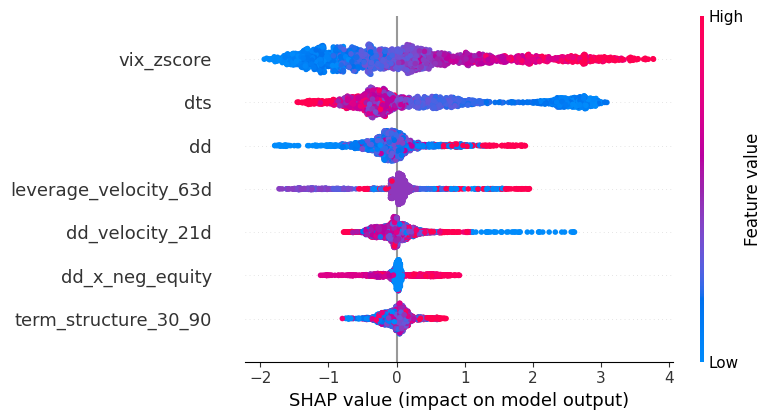

In [6]:
import shap
explainer = shap.TreeExplainer(fold_model)
# Look at the most recent test set where it's failing
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)